In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d.axes3d import Axes3D
from sklearn.datasets import make_regression

# Удобный формат отображения чисел с 4 знаками после запятой
np.set_printoptions(formatter={'float_kind': '{:.4f}'.format})

In [3]:
# данные для регрессии

#кол-во наблюдений
n = 1600

#создание матрицы признаков с добавлением вектора констант
X, y = make_regression(n_samples=n, n_features=1, n_informative=1, noise=10, random_state=101)
X = np.column_stack((np.ones(n), X))

# истинное значение параметров линейной регрессии по формуле
real_params = np.linalg.inv(X.T @ X) @ X.T @ y

print(f'Реальные оптимальные параметры, минимизирующие функцию потерь -- {real_params}')

Реальные оптимальные параметры, минимизирующие функцию потерь -- [0.0927 22.8151]


Алгоритм обыкновенного градиентного спуска GD: 
$$\displaystyle \boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \alpha \cdot \nabla \mathcal{L}(\boldsymbol{\theta}_t)$$

Алгоритм сошелся за 5 шагов в точку [0.0927 22.8151] 
Истинная оптимальная точка [0.0927 22.8151]


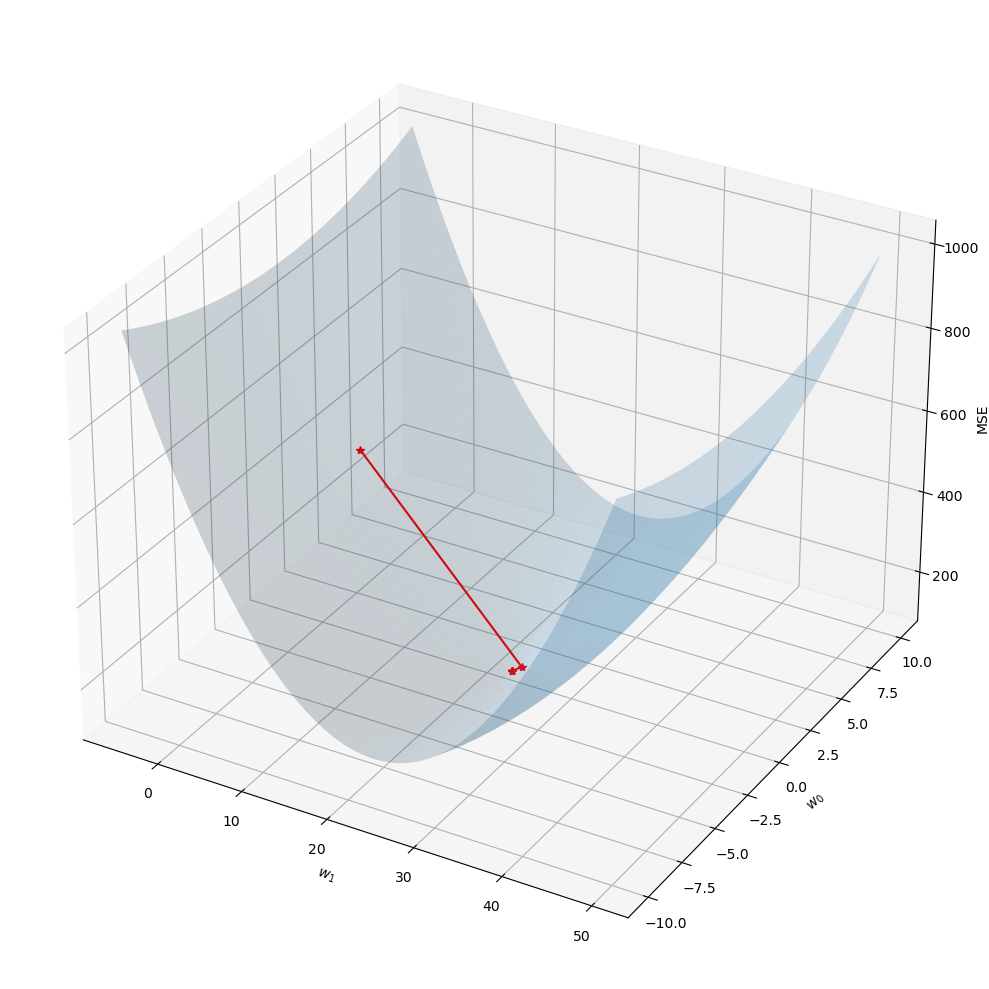

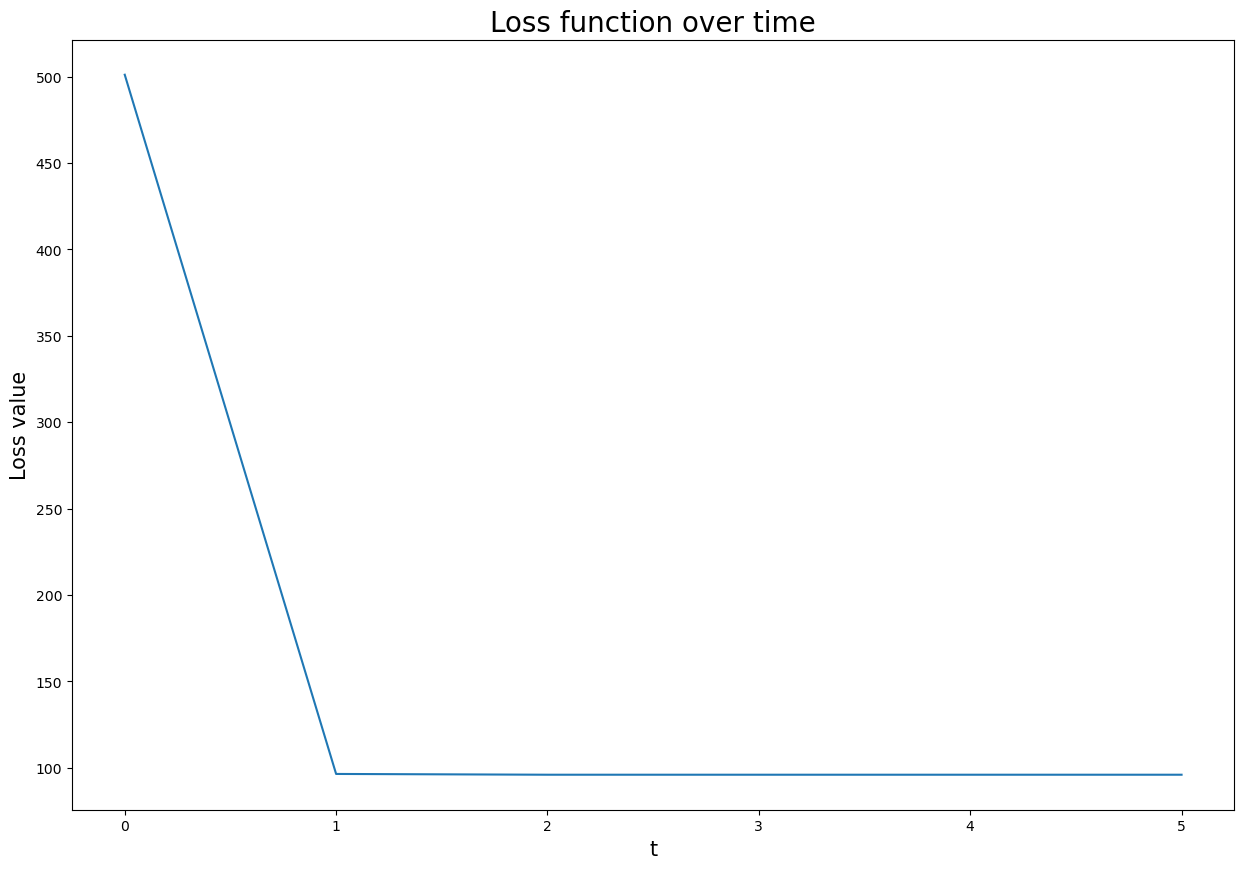

In [456]:
def grad(X, y, w):
    return X.T @ (X @ w - y)

def GD(a, n_epoch):
    # Инициализация начальной позиции:
    current_theta = np.random.rand(X.shape[1]) * 10
    # Создание списка всех положений:
    points = [current_theta]

    
    # Алгоритм спуска
    for t in range(n_epoch):
        # Шаг спуска
        next_theta = current_theta - a * grad(X, y, current_theta)
            
        #добавление точки в список
        points.append(next_theta)
            
        # критерий остановки внутреннего цикла
        if np.all(np.abs(next_theta - current_theta) < 10 ** (-4)):
             break
                
        # Переход к следующему шагу спуска, если алгоритм не сошелся
        current_theta = next_theta    

    # Возврат списка всех значений параметров
    return np.array(points)
    
    
    
# ВЫЗОВ ФУНКЦИИ    

# Величина шага
a = 0.0006

#количество шагов
n_epoch = 100

points = GD(a, n_epoch)    
       
    
    
# РЕЗУЛЬТАТЫ    
print(f'Алгоритм сошелся за {points.shape[0] - 1} шагов в точку {points[-1]} \nИстинная оптимальная точка {real_params}')    
    
    
# ВИЗУАЛИЗАЦИЯ ЗНАЧЕНИЯ ФУНКЦИИ ПОТЕРЬ В ПРОСТРАНСТВЕ ПАРАМЕТРОВ
def mse(w1, w0):
    y_pred = X @ np.array([w0, w1])
    return np.mean((y - y_pred) ** 2)

# Данные параметров для отрисовки функции потерь
coefs_a = np.linspace(-5, 50, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)

# Данные значений функции потерь
zs = np.array([mse(i, j) for i, j in zip(np.ravel(w1), np.ravel(w0))])
Z = zs.reshape(w1.shape)


# Создание графика для нанесения значений функции потерь
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')


# Нанесение данных на созданный график и полученного значения моделью
ax.plot_surface(w1, w0, Z, alpha=.2)
# Траектория градиентного спуска
ax.plot(points[:, 1], points[:, 0], [mse(w1, w0) for w0, w1 in points], '-*r')

ax.set_xlabel(r'$w_1$') 
ax.set_ylabel(r'$w_0$')
ax.set_zlabel('MSE', rotation=90)
plt.tight_layout()
plt.show()


# ВИЗУАЛИЗАЦИЯ УМЕНЬШЕНИЯ ЗНАЧЕНИЯ ФУНКЦИИ ПОТЕРЬ ВО ВРЕМЕНИ
losses = [mse(w1, w0) for w0, w1 in points]
t = list(range(len(losses)))
figure = plt.figure(figsize=(15,10))
plt.plot(t, losses)
plt.title('Loss function over time', fontsize=20)
plt.xlabel('t', fontsize=15)  
plt.ylabel('Loss value', fontsize=15);

Алгоритм стохастического градиентного спуска SGD: 
$$
\displaystyle \boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \alpha \cdot \hat{\nabla} \mathcal{L}(\boldsymbol{\theta}_t)
$$
Где $ \displaystyle \hat{\nabla} \mathcal{L}(\boldsymbol{\theta}_t)$ - Несмещенная Монте-Карло оценка полного градиента, сделанная по мини батчу

Алгоритм сошелся за 2 шагов в точку [2.1076 13.8644] 
Истинная оптимальная точка [0.0927 22.8151]


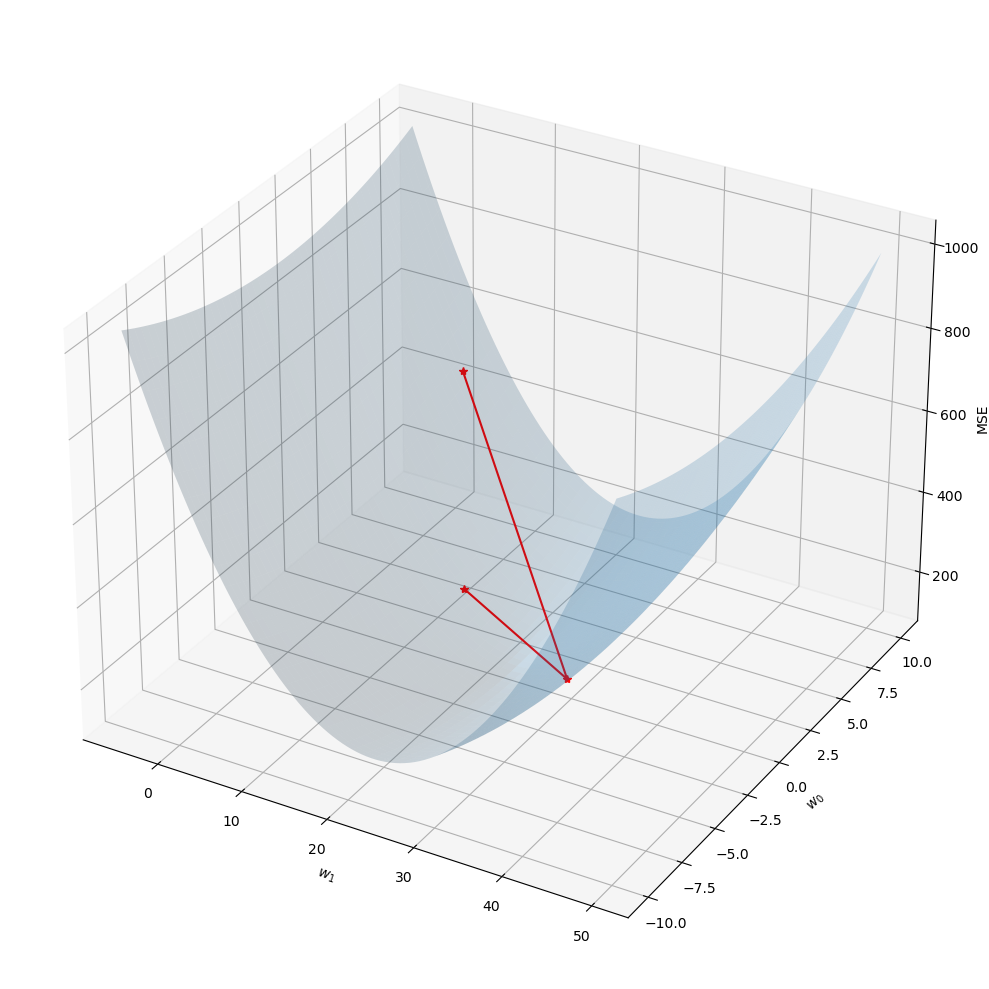

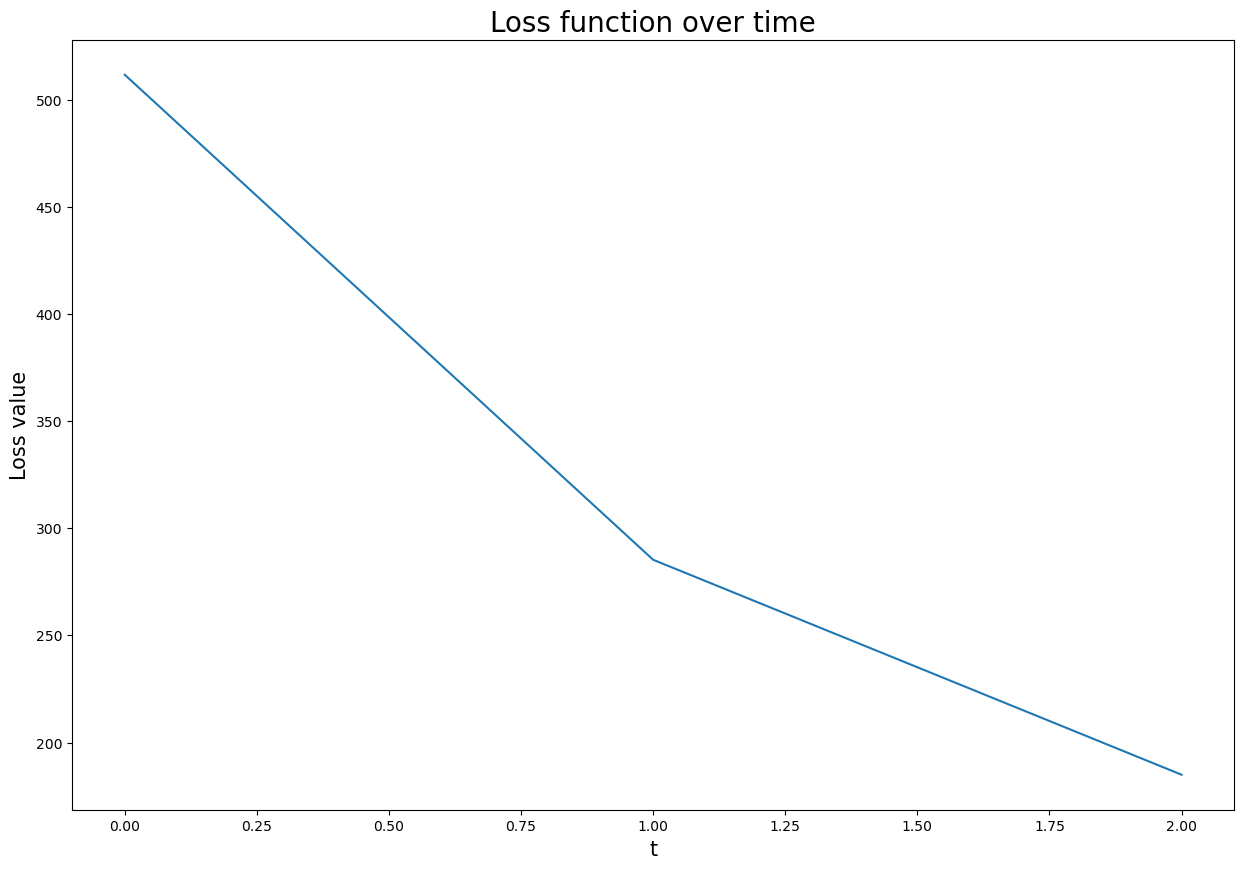

In [540]:
def grad(X_batch, y_batch, w):
    return X_batch.T @ (X_batch @ w - y_batch)

def SGD(a, batch_size, n_epochs):
    # Количество мини-батчей в одной эпохе
    batches_amount = int(X.shape[0] / batch_size)
    
    # Инициализация начальной позиции:
    current_theta = np.random.rand(X.shape[1]) * 10
    # Создание списка всех значений параметров:
    points = [current_theta]
    
    # Булева переменная, сошелся ли алгоритм:
    converged = False

    
    # Цикл прохода по выбронному количеству эпох 
    for epoch in range(1, n_epochs + 1):
        # Перемешивание выборки
        indices = np.random.permutation(X.shape[0])
        y_shuffled = y[indices]
        X_shuffled = X[indices]
        
        # Проход по одной эпохе
        for t in range(batches_amount):
            # Создание мини-батча
            X_batch = X_shuffled[batch_size * t: batch_size * (t + 1)]
            y_batch = y_shuffled[batch_size * t: batch_size * (t + 1)]
            
            # Шаг стохастического спуска
            next_theta = current_theta - a * grad(X_batch, y_batch, current_theta)
            
            #добавление точки в список
            points.append(next_theta)
            
            # критерий остановки внутреннего цикла
            if np.all(np.abs(next_theta - current_theta) < 10 ** (-4)):
                converged = True
                break
                
            # Переход к следующему шагу спуска, если алгоритм не сошелся
            current_theta = next_theta    
        
        # критерий остановки внешнего цикла
        if converged:
            break
     
    # Возврат списка всех значений параметров
    return np.array(points)
    
    
    
# ВЫЗОВ ФУНКЦИИ    
a = 0.001

# размер мини-батча
batch_size = 1600

#количество проходок по мини-батчам
n_epochs = 2
    
points = SGD(a, batch_size, n_epochs)    
       
    
    
# РЕЗУЛЬТАТЫ    
print(f'Алгоритм сошелся за {points.shape[0] - 1} шагов в точку {points[-1]} \nИстинная оптимальная точка {real_params}')    
    
    
# ВИЗУАЛИЗАЦИЯ ЗНАЧЕНИЯ ФУНКЦИИ ПОТЕРЬ В ПРОСТРАНСТВЕ ПАРАМЕТРОВ
def mse(w1, w0):
    y_pred = X @ np.array([w0, w1])
    return np.mean((y - y_pred) ** 2)

# Данные параметров для отрисовки функции потерь
coefs_a = np.linspace(-5, 50, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)

# Данные значений функции потерь
zs = np.array([mse(i, j) for i, j in zip(np.ravel(w1), np.ravel(w0))])
Z = zs.reshape(w1.shape)


# Создание графика для нанесения значений функции потерь
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')


# Нанесение данных на созданный график и полученного значения моделью
ax.plot_surface(w1, w0, Z, alpha=.2)
# Траектория градиентного спуска
ax.plot(points[:, 1], points[:, 0], [mse(w1, w0) for w0, w1 in points], '-*r')

ax.set_xlabel(r'$w_1$') 
ax.set_ylabel(r'$w_0$')
ax.set_zlabel('MSE', rotation=90)
plt.tight_layout()
plt.show()


# ВИЗУАЛИЗАЦИЯ УМЕНЬШЕНИЯ ЗНАЧЕНИЯ ФУНКЦИИ ПОТЕРЬ ВО ВРЕМЕНИ
losses = [mse(w1, w0) for w0, w1 in points]
t = list(range(len(losses)))
figure = plt.figure(figsize=(15,10))
plt.plot(t, losses)
plt.title('Loss function over time', fontsize=20)
plt.xlabel('t', fontsize=15)  
plt.ylabel('Loss value', fontsize=15);

Алгоритм Adam, объединяющий в себе добавление инерции (Momentum), нормировку смещения (RMSprop), а также оценку градиента по мини-батчам (SGD / mini-batch GD):
$$
\begin{cases}
\mathbf{m_{t-1}} = \beta_1 \cdot \mathbf{m_t} + (1 - \beta_{1}) \cdot \hat{\nabla} \mathcal{L}(\mathbf{\theta}_t) 
\\
\mathbf{v_{t-1}} = \beta_2 \cdot \mathbf{v_t} + (1 - \beta_{2}) \cdot \hat{\nabla} \mathcal{L}(\mathbf{\theta}_t) ^ 2
\\
\mathbf{\theta_{t+1}} = \mathbf{\theta_{t}} - \frac{\alpha}{\sqrt{\frac{1}{1 - \beta_{2} ^ t} \cdot \mathbf{v_t}} + \varepsilon} \odot \frac{\mathbf{m_t}}{1 - \beta_{1} ^ t}
\end{cases}
$$

Алгоритм сошелся за 8000 шагов в точку [0.0972 22.8070] 
Истинная оптимальная точка [0.0927 22.8151]


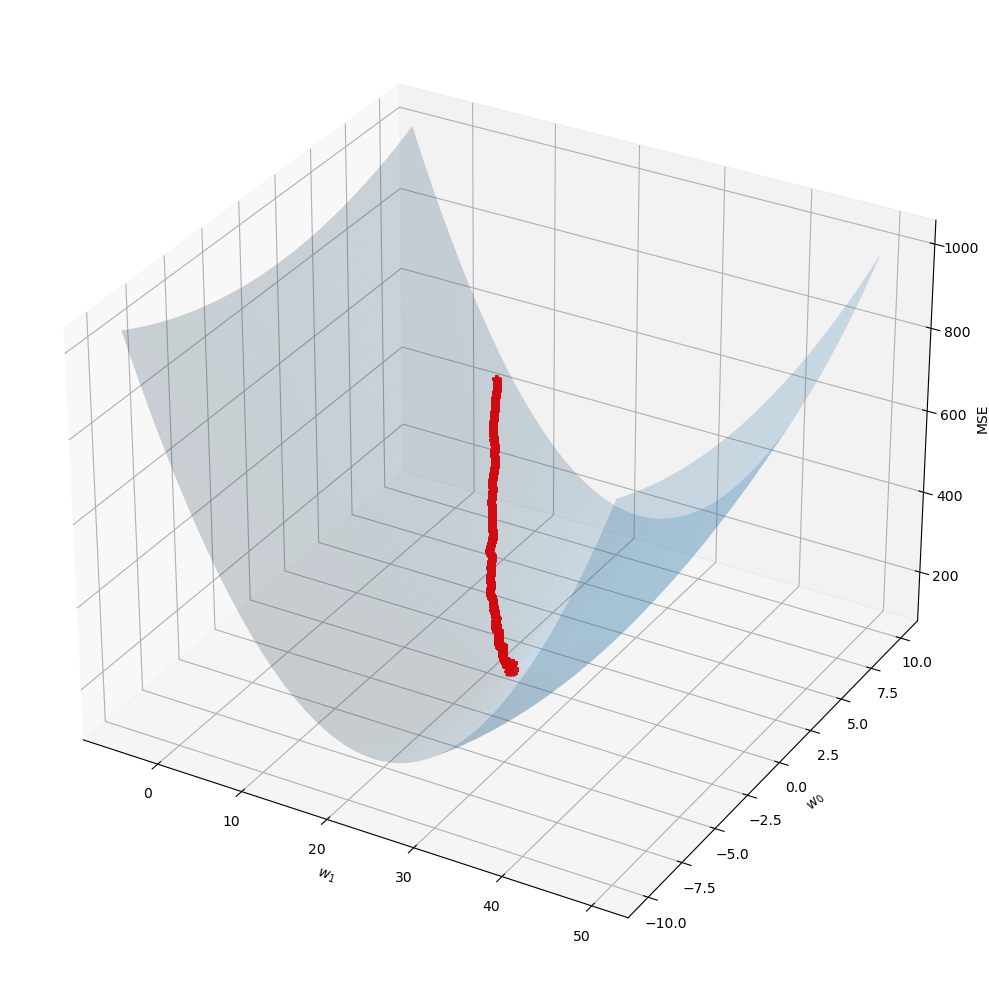

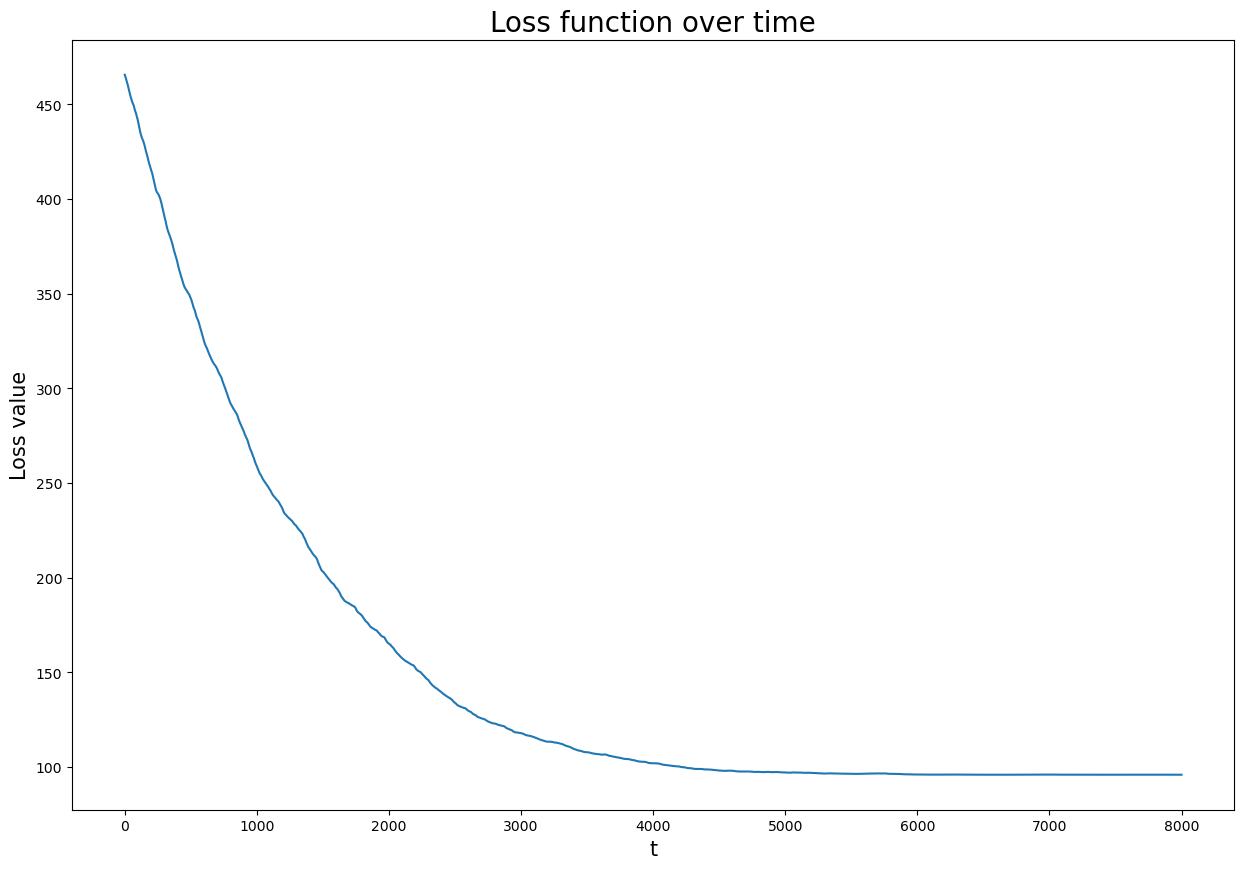

In [80]:
# Вычисление градиента для линейной регрессии
def grad(X_batch, y_batch, w):
    return X_batch.T @ (X_batch @ w - y_batch)


# Алгоритм Adam
def Adam(a, b1, b2, batch_size, n_epoch, *, eps = 10 ** (-8)):
    # Инициализиация начальной позиции 
    current_theta = np.random.randn(X.shape[1]) * 5
    # Cоздание списка для записи всех значений параметров
    points = [current_theta]
    
    # Инициализиация первых моментов для инерции
    past_m = np.zeros(X.shape[1])
    
    # Инициализиация вторых моментов для коррекции вектора градиента 
    past_v = np.zeros(X.shape[1])
    
    # Булева переменная, сошелся ли алгоритм:
    converged = False
    
    # Количество мини-батчей в одной эпохе
    batches_amount = int(X.shape[0] / batch_size)
    
    # Цикл прохода по выбронному количеству эпох 
    for epoch in range(n_epoch):
        # Перемешивание выборки
        indices = np.random.permutation(X.shape[0])
        y_shuffled = y[indices]
        X_shuffled = X[indices]

        # Проход по одной эпохе
        for t in range(batches_amount):
            X_batch = X_shuffled[batch_size * t : batch_size * (t + 1)]
            y_batch = y_shuffled[batch_size * t : batch_size * (t + 1)]
            
            # Вычисление градиента
            g_t = grad(X_batch, y_batch, current_theta)

            # обновление первого момента, отвечающего за инерцию
            current_m = b1 * past_m + (1 - b1) * g_t
            past_m = current_m
            
            # обновление второго момента, отвечающего за длину вектора смещения 
            current_v = b2 * past_v + (1 - b2) * g_t ** 2
            past_v = current_v

            # коррекция смещения
            global_step = epoch * batches_amount + t + 1
            m_hat = current_m / (1 - b1 ** global_step)
            v_hat = current_v / (1 - b2 ** global_step)

            # шаг алгоритма
            step = a * m_hat / (np.sqrt(v_hat) + eps)
            next_theta = current_theta - step

            # критерий остановки
            if np.all(np.abs(next_theta - current_theta) < 1e-5):
                converged = True
                break

            current_theta = next_theta
            points.append(current_theta)
        
        # Критерий остановки внешнего цикла по эпохам
        if converged:
            break

    # возврат списка всех значений параметров, перебранных при спуске
    return np.array(points)




# ВЫЗОВ ФУНКЦИИ
#learning rate
a = 0.01

# b1 — дисконтирующий фактор прошлых градиентов в инерции
b1 = 0.9

# b2 — дисконтирующий фактор прошлых градиентов в нормировке смещения
b2 = 0.999

# количество наблюдений в мини-батче
batch_size = 1

#количество проходок по мини-батчам
n_epoch = 5

# Вызов самой функции
points = Adam(a, b1, b2, batch_size, n_epoch)




# ВЫВОД РЕЗУЛЬТАТОВ 
print(f'Алгоритм сошелся за {points.shape[0] - 1} шагов в точку {points[-1]} \nИстинная оптимальная точка {real_params}')    

# ВИЗУАЛИЗАЦИЯ ПРОСТРАНСТВА ПАРАМЕТРОВ
def mse(w1, w0):
    y_pred = X @ np.array([w0, w1])
    return np.mean((y - y_pred) ** 2)

# Данные параметров для отрисовки функции потерь
coefs_a = np.linspace(-5, 50, num=100)
coefs_b = np.linspace(-10, 10, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)

# Данные значений функции потерь
zs = np.array([mse(i, j) for i, j in zip(np.ravel(w1), np.ravel(w0))])
Z = zs.reshape(w1.shape)


# Создание графика для нанесения значений функции потерь
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')


# Нанесение данных на созданный график и полученного значения моделью
ax.plot_surface(w1, w0, Z, alpha=.2)
# Траектория Adam
ax.plot(points[:, 1], points[:, 0], [mse(w1, w0) for w0, w1 in points], '-*r')

ax.set_xlabel(r'$w_1$') 
ax.set_ylabel(r'$w_0$')
ax.set_zlabel('MSE', rotation=90)
plt.tight_layout()
plt.show()

# ВИЗУАЛИЗАЦИЯ УМЕНЬШЕНИЯ ЗНАЧЕНИЯ ФУНКЦИИ ПОТЕРЬ ВО ВРЕМЕНИ
losses = [mse(w1, w0) for w0, w1 in points]
t = list(range(len(losses)))
figure = plt.figure(figsize=(15,10))
plt.plot(t, losses)
plt.title('Loss function over time', fontsize=20)
plt.xlabel('t', fontsize=15)  
plt.ylabel('Loss value', fontsize=15);